# 1. import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 2. read

In [2]:
TIMEZONE = "America/New_York"
HORIZON = 14 * 24

data = pd.read_csv("cleaned_data/rdu_51_clean.csv")

data["DATE"] = (
    pd.to_datetime(data["DATE"], format="ISO8601", utc=True)
    .dt.tz_convert(TIMEZONE)
)

data = data.sort_values("DATE")

CUTOFF = pd.Timestamp("2026-09-17 00:00", tz=TIMEZONE)
data = data.loc[data["DATE"] < CUTOFF].copy()

# Label each :51 observation with its local hour.
data.index = (
    data["DATE"]
    - pd.to_timedelta(data["DATE"].dt.minute, unit="m")
    - pd.to_timedelta(data["DATE"].dt.second, unit="s")
)
data.index.name = "hour"

weather_columns = [
    "temperature",
    "dew_point_temperature",
    "relative_humidity",
    "sea_level_pressure",
    "wind_speed",
]

weather_columns = [
    column for column in weather_columns if column in data.columns
]

data[weather_columns] = data[weather_columns].apply(
    pd.to_numeric, errors="coerce"
)

print("Number of observations:", len(data))

Number of observations: 49881


# 3. model

In [3]:
def make_features(origin):
    past = data.loc[
        (data["DATE"] >= origin - pd.Timedelta(days=7))
        & (data["DATE"] < origin),
        weather_columns,
    ]

    recent = past.loc[
        past.index >= origin - pd.Timedelta(hours=24)
    ]

    features = {}

    for column in weather_columns:
        features[f"{column}_last_hour"] = (
            past[column]
            .reindex([origin - pd.Timedelta(hours=1)])
            .iloc[0]
        )

        features[f"{column}_mean_24h"] = recent[column].mean()
        features[f"{column}_mean_7d"] = past[column].mean()

    hours = pd.date_range(origin, periods=HORIZON, freq="h")

    X = pd.DataFrame(features, index=hours)

    X["lead_hour"] = np.arange(HORIZON)
    X["hour_sin"] = np.sin(2 * np.pi * hours.hour / 24)
    X["hour_cos"] = np.cos(2 * np.pi * hours.hour / 24)
    X["day_sin"] = np.sin(
        2 * np.pi * hours.dayofyear / 365.25
    )
    X["day_cos"] = np.cos(
        2 * np.pi * hours.dayofyear / 365.25
    )

    return X

# 4. training

In [4]:
def make_training_data(end):
    first_origin = (
        data.index.min() + pd.Timedelta(days=7)
    ).ceil("D")

    last_origin = end - pd.Timedelta(hours=HORIZON)

    origins = pd.date_range(
        first_origin,
        last_origin,
        freq="D",
    )

    X_parts = []
    y_parts = []

    for origin in origins:
        X = make_features(origin)
        y = data["temperature"].reindex(X.index)

        valid = y.notna()

        X_parts.append(X.loc[valid])
        y_parts.append(y.loc[valid])

    return (
        pd.concat(X_parts, ignore_index=True),
        pd.concat(y_parts, ignore_index=True),
    )


def make_model():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        RandomForestRegressor(
            n_estimators=100,
            max_depth=16,
            min_samples_leaf=20,
            max_features=0.8,
            max_samples=0.8,
            random_state=42,
            n_jobs=-1,
        ),
    )

# 5. 2025 test

In [5]:
validation_origin = pd.Timestamp(
    "2025-09-17 00:00", tz=TIMEZONE
)

X_train, y_train = make_training_data(validation_origin)
X_validation = make_features(validation_origin)

model = make_model()
model.fit(X_train, y_train)

validation = pd.DataFrame(
    {
        "actual": data["temperature"].reindex(X_validation.index),
        "predicted": model.predict(X_validation),
    },
    index=X_validation.index,
)

scored = validation.dropna(subset=["actual"])

mae = mean_absolute_error(
    scored["actual"], scored["predicted"]
)

rmse = np.sqrt(
    mean_squared_error(scored["actual"], scored["predicted"])
)

print("Training samples:", len(X_train))
print("Validation observations:", len(scored))
print(f"Validation MAE: {mae:.2f} °C")
print(f"Validation RMSE: {rmse:.2f} °C")

Training samples: 569628
Validation observations: 335
Validation MAE: 2.75 °C
Validation RMSE: 3.43 °C


# 6. result

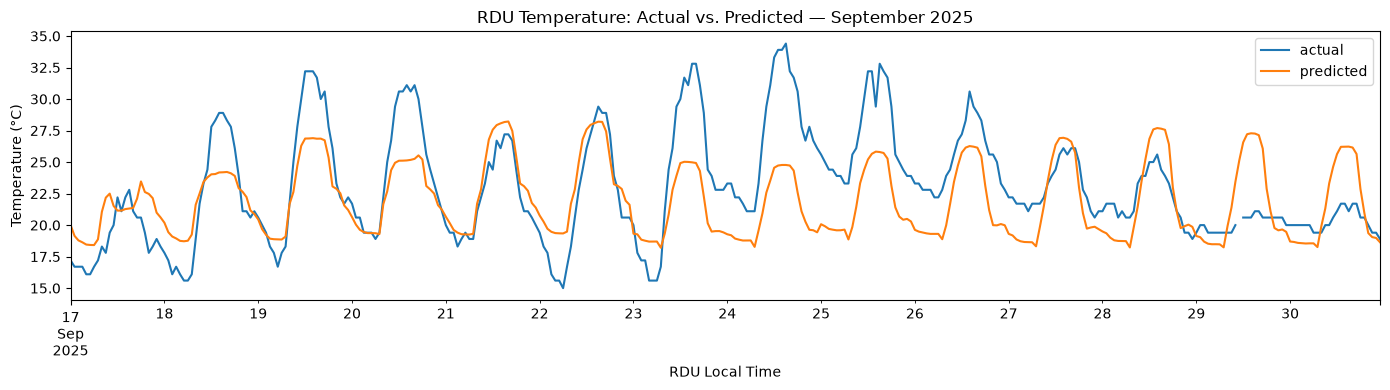

In [6]:

validation.plot(figsize=(14, 4))

plt.title("RDU Temperature: Actual vs. Predicted — September 2025")
plt.xlabel("RDU Local Time")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()

# 7. 2026

In [7]:
X_train, y_train = make_training_data(CUTOFF)
X_forecast = make_features(CUTOFF)

final_model = make_model()
final_model.fit(X_train, y_train)

forecast = pd.DataFrame(
    {
        "hour_local": X_forecast.index,
        "predicted_temperature": final_model.predict(X_forecast),
    }
)

forecast.to_csv("rdu_random_forest_predictions.csv", index=False)

print("Forecast hours:", len(forecast))
print("Saved: rdu_random_forest_predictions.csv")

forecast.head()

Forecast hours: 336
Saved: rdu_random_forest_predictions.csv


,hour_local,predicted_temperature
0,2026-09-17 00:00:00-04:00,20.385220
1,2026-09-17 01:00:00-04:00,20.269190
2,2026-09-17 02:00:00-04:00,20.080096
3,2026-09-17 03:00:00-04:00,19.892709
4,2026-09-17 04:00:00-04:00,19.643368
